# Patient transfer adaptation through a crisis: The dynamics of a Hospitals Network during the COVID-19 pandemic.

**Basado en los trabajos realizados por:** Cicchini Tomás, Salgado Ariel, Otero Lisandro, Goldman Mariano, Yacobitti Alejandro, Doldan Victoria, Kochen Silvia, Boechi Leonardo, Caridi Inés.

_Instituto del Cálculo (UBA-CONICET), Hospital de Alta Complejidad en Red Nestor Carlos Kirchner, ENYS (CONICET-HEC-UNAJ), y desarrollador free-lance._


In [1]:
import sys
import os
sys.path.append("..") # agrega raiz del proyecto a path

from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *


import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import matplotlib.lines as mlines
import ast

# from scripts import bases, init_notebook as init

# from src.config import crear_directorios_overleaf
# crear_directorios_overleaf()

In [2]:
# Carga todos los datos del proyecto de una vez
ctx_datos = init_notebook(data_path="../data", drop_missing=True)

df_pacientes    = ctx_datos["df_pacientes"]
traslados       = ctx_datos["traslados"]
hosp_coords     = ctx_datos["hosp_coords"]
municipios      = ctx_datos["municipios"]
municipios_amba = ctx_datos["municipios_amba"]


Cargando datos geográficos...
  -> 14 hospitales con coordenadas
  -> 9 municipios AMBA cargados
Cargando datos de pacientes...

[AVISO] Ignorando 1 hospitales no registrados:
  - 'MODULO HOSPITALARIO 8 LZ' (61 registros)
Total de registros eliminados: 61
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  -> 29,635 registros | 27,233 pacientes únicos
  -> 1,681 traslados reconstruidos

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29635
Pacientes únicos:   27233
Hospitales únicos:  14
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4018


## The hospital network and the data.

**Contexto:** El trabajo en red permite optimizar recursos en momentos críticos.  
**Impacto COVID-19:** La pandemia puso en crisis a los sistemas de salud y obligó a adaptar infraestructuras.  
**Red Sudeste:** El sistema informático recolectó datos de camas y traslados de 14 hospitales de la Red Sudeste. Abarca cuatro municipios: Quilmes (QU), Almirante Brown (AB), Florencio Varela (FV) y Berazategui (BE), cubriendo 661 km² y casi 2 millones de habitantes.


In [3]:
# Mapas (Paneles A, B y C)
# A. Aquí se visualiza la Provincia de Buenos Aires (PBA)

# ----------------------------
# cargar datos
# ----------------------------

### ⚠️ OPCIÓN E (Clúster 1): Generación de Mapas Base
*Nota: Este bloque carga shapes y dibuja mapas. Existen versiones unificadas de esto en src/visualizacion.py.*

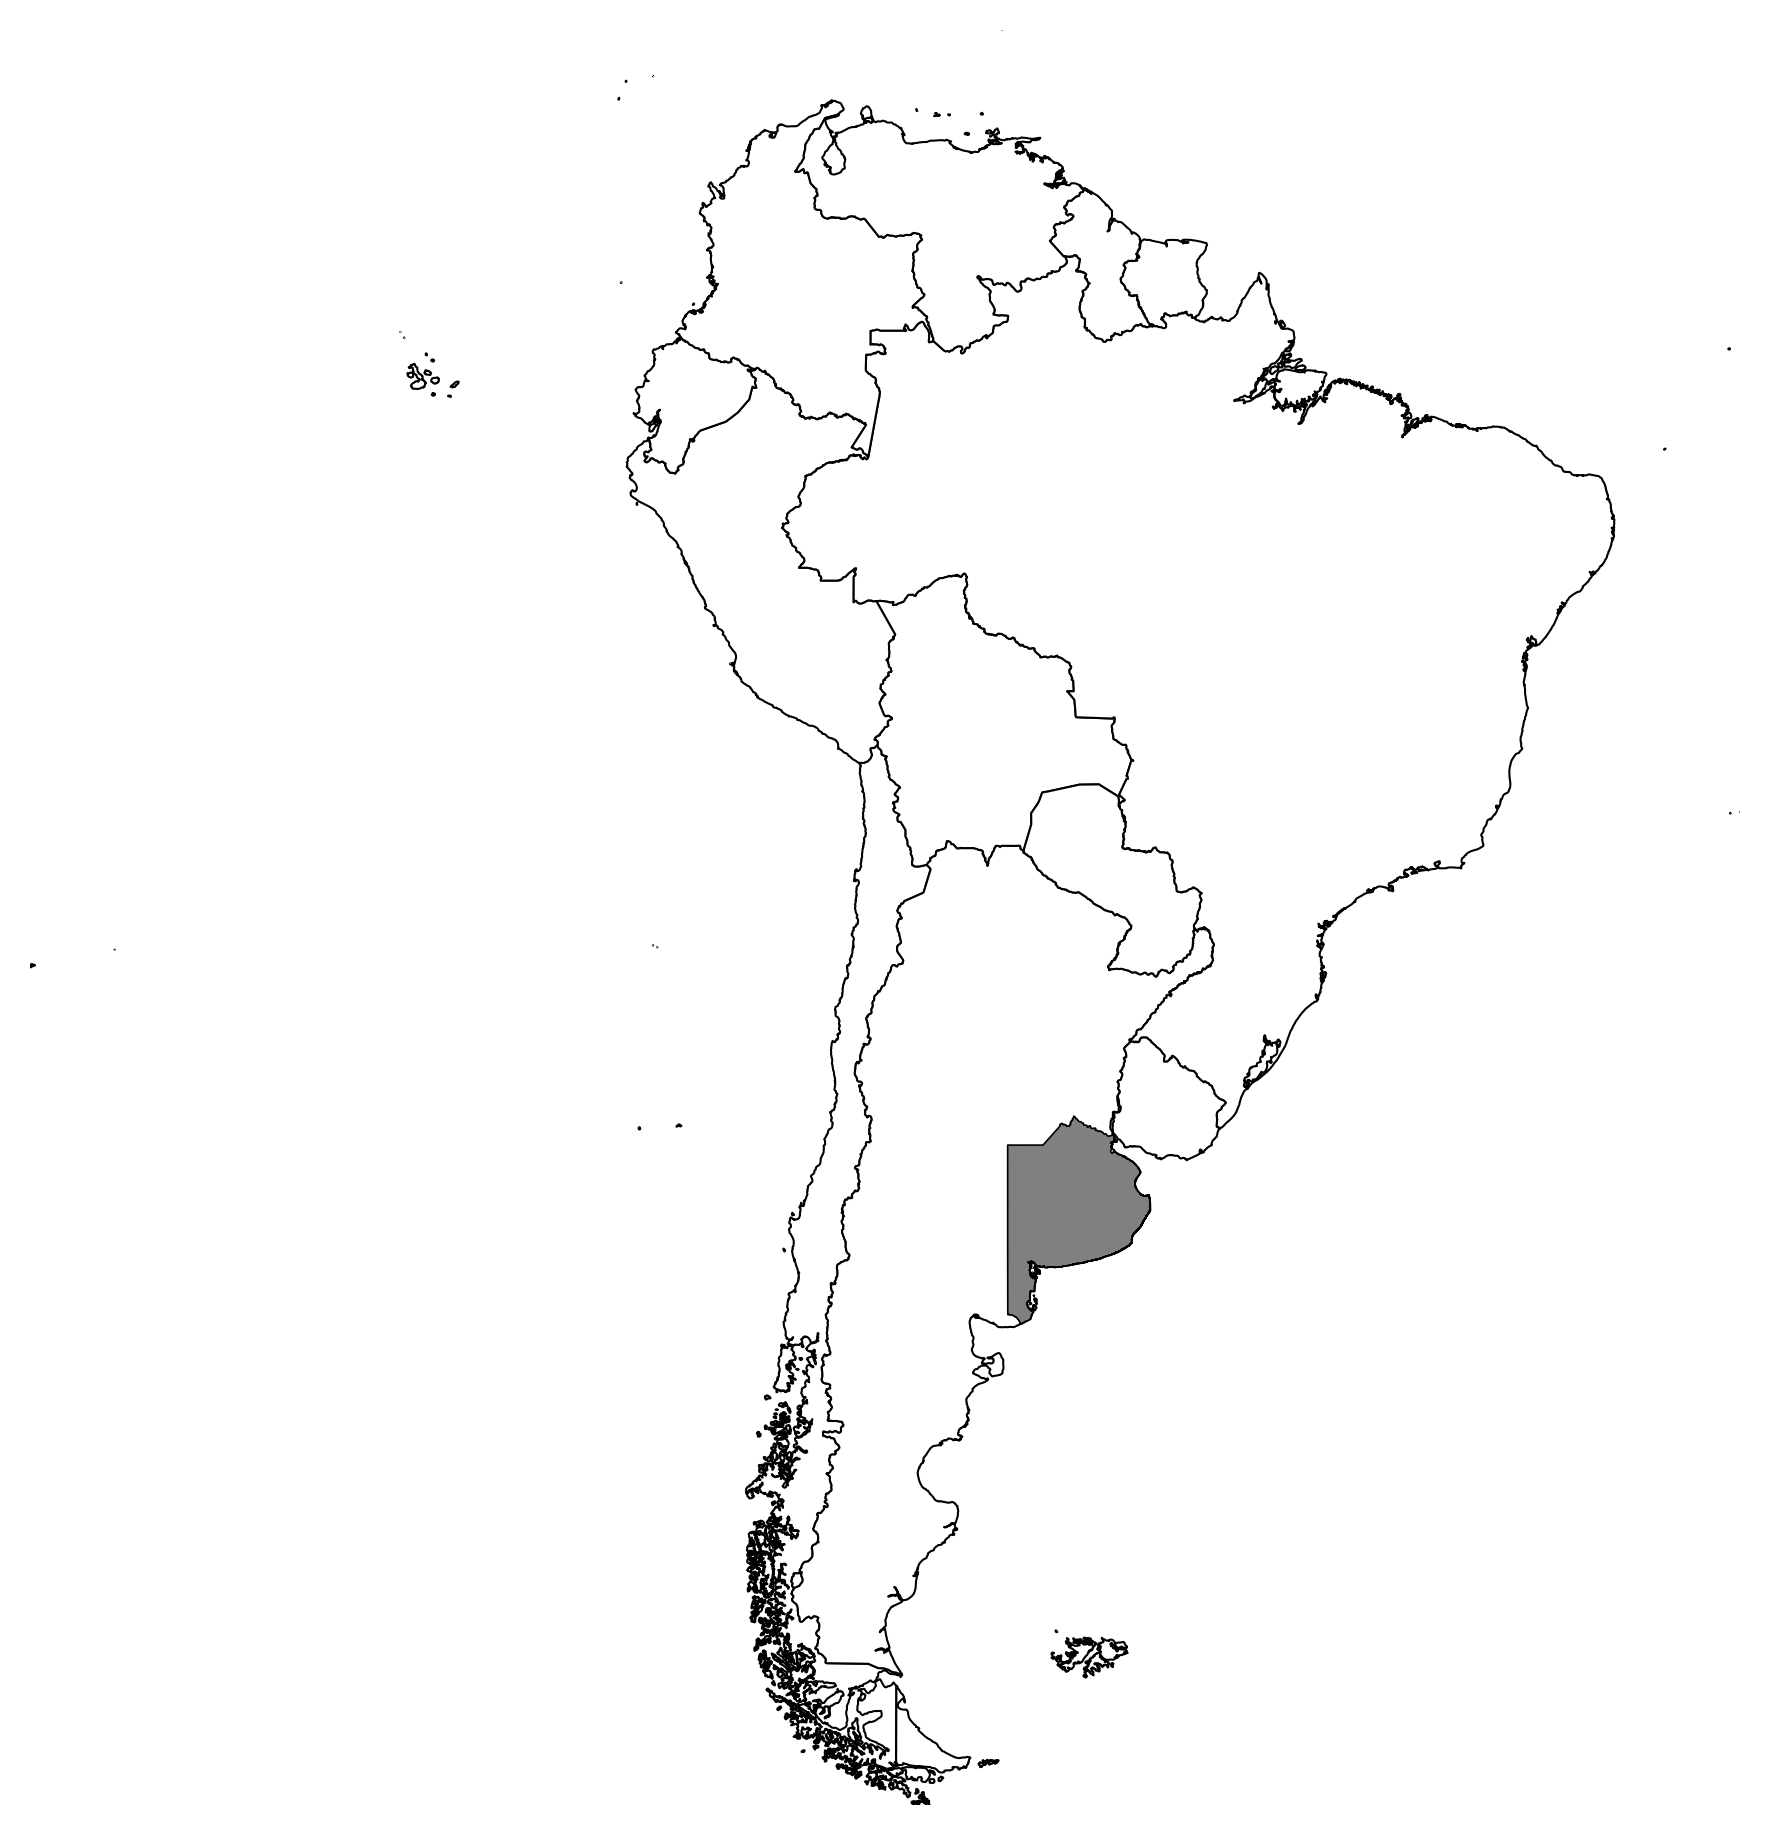

In [4]:


# -------------------------
# 1. Cargar datos
# -------------------------
paises = gpd.read_file("../data/ne_countries/ne_10m_admin_0_countries.shp") # https://github.com/nvkelso/natural-earth-vector/tree/master/10m_cultural
sudamerica = paises[paises["CONTINENT"] == "South America"]

provincias = gpd.read_file("../data/provincias_ign/provinciaPolygon.shp")
pba = provincias[provincias["nam"] == "Buenos Aires"]

# -------------------------
# 2. PROYECCIÓN (El truco para que no se vea estirado)
# -------------------------
sudamerica = sudamerica.to_crs(epsg=3857)
pba = pba.to_crs(epsg=3857)

# -------------------------
# 3. Plot con mejoras estéticas
# -------------------------
# Mantenemos el dpi=80 acá para la visualización en pantalla, 
# la calidad de exportación la definiremos en el savefig.
fig, ax = plt.subplots(figsize=(6, 8), dpi=300)

# Sudamérica (Fondo)
sudamerica.plot(
    ax=ax,
    color="white",      
    edgecolor="black",  
    linewidth=0.5        
)

# Buenos Aires resaltada
pba.plot(
    ax=ax,
    color="#808080",      
    edgecolor="black",
    linewidth=0.4            
)

# -------------------------
# 4. Ajustes de encuadre
# -------------------------
minx, miny, maxx, maxy = sudamerica.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Título con mejor fuente
# ax.set_title(
#     "Ubicación de Buenos Aires en Sudamérica",
#     fontsize=12,
#     fontweight="bold",
#     pad=20,
#     loc="center"
# )

ax.axis("off")

plt.tight_layout()

# -------------------------
# 5. Exportación de Alta Calidad
# -------------------------
# Definir la ruta y crearla si no existe
ruta_salida = "results/outputs/geo"
os.makedirs(ruta_salida, exist_ok=True)

nombre_archivo = f"{ruta_salida}/mapa_buenos_aires"

# Exportar como PNG (Raster)
# dpi=300 es estándar de impresión. Puedes subirlo a 600 si necesitas extremo detalle.
plt.savefig(
    f"{nombre_archivo}.png", 
    dpi=300, 
    bbox_inches="tight", # Asegura fondo blanco (a veces los notebooks lo hacen transparente)
    transparent=True
)

# Exportar como Vectorial (SVG y PDF)
# SVG es ideal para editar en Illustrator/Inkscape o usar en web.
plt.savefig(
    f"{nombre_archivo}.svg", 
    format="svg", 
    bbox_inches="tight",
    transparent=True
)

# PDF es el formato preferido si vas a insertarlo en un documento de LaTeX o Word sin perder calidad.
guardar_pdf('gen_mapa_buenos_aires_global', subcarpeta='general')

# Siempre mostrar el gráfico DESPUÉS de guardarlo. 
# Si haces show() antes, savefig() guardará una imagen en blanco.
plt.show()

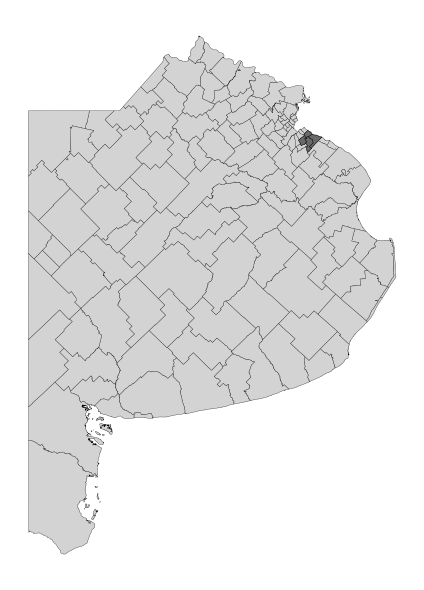

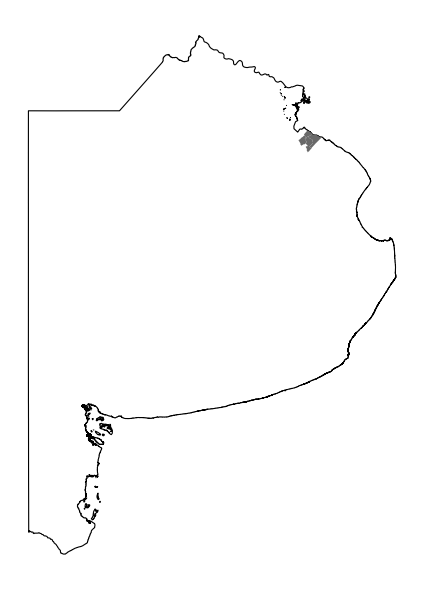

In [5]:
import matplotlib.pyplot as plt
import os # Asegurarnos de importar os

# -------------------------
# Cargar municipios (partidos)
# -------------------------
deptos = cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")

# Solo partidos de la provincia de Buenos Aires
pba = deptos[
    deptos["in1"].astype(str).str.startswith("06")
]

# -------------------------
# Partidos de la red sudeste
# -------------------------
red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI",
    # "LANUS",
    # "LOMAS DE ZAMORA",
    # "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]

# Definir y crear la ruta base de salida si no existe
ruta_salida = "results/outputs/geo"
os.makedirs(ruta_salida, exist_ok=True)


# =====================================================
# OPTION 1
# Todos los partidos + red sudeste resaltada
# =====================================================

fig, ax = plt.subplots(figsize=(6,6))

# Todos los partidos
pba.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

# Partidos de la red sudeste
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="black",
    linewidth=0.3
)

# ax.set_title(
#     "Ubicación de la Red Sudeste en la PBA",
#     fontsize=13,
#     pad=10
# )

ax.axis("off")

plt.tight_layout()

# --- Exportación Opción 1 ---
nombre_archivo_1 = f"{ruta_salida}/mapa_red_sudeste_opcion1"

plt.savefig(f"{nombre_archivo_1}.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig(f"{nombre_archivo_1}.svg", format="svg", bbox_inches="tight", transparent=True)
guardar_pdf('gen_mapa_redsudeste_opt1_global', subcarpeta='general')

plt.show() # Mostrar el gráfico de la opción 1


# =====================================================
# OPTION 2
# Provincia blanca sin divisiones + red sudeste
# =====================================================

# Crear geometría de toda la provincia
pba_union = pba.dissolve()

fig, ax = plt.subplots(figsize=(6,6))

# Provincia completa
pba_union.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.8
)

# Partidos de la red
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="none"
)

# ax.set_title(
#     "Ubicación de la Red Sudeste en la PBA",
#     fontsize=13,
#     pad=10
# )

ax.axis("off")

plt.tight_layout()

# --- Exportación Opción 2 ---
nombre_archivo_2 = f"{ruta_salida}/mapa_red_sudeste_opcion2"

plt.savefig(f"{nombre_archivo_2}.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig(f"{nombre_archivo_2}.svg", format="svg", bbox_inches="tight", transparent=True)
guardar_pdf('gen_mapa_redsudeste_opt2_global', subcarpeta='general')

plt.show() # Mostrar el gráfico de la opción 2

In [6]:
# C. Los asentamientos cercanos

# RE.NA.BA.P

In [8]:

import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

# Imports y configuraciones basicas
import os
import ast
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

# ==========================================
# CONFIGURACIONES GLOBALES
# ==========================================
sns.set_style("whitegrid") 
# from src.config import crear_directorios_overleaf
# crear_directorios_overleaf()  # Crea subcarpetas en graficos_overleaf/
# CARGA Y LIMPIEZA DE DATOS (Nomenclatura completa)
# ==========================================
df_base = pd.read_excel("../data/pacientes.xlsx")
hospitales = pd.read_csv("../data/hospitales_coordenadas.csv")

# Diccionarios de referencia para hospitales
dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
hospitales['color_rgb'] = hospitales['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# --- RECUPERADO: El renombre COMPLETO de columnas ---
df_base = df_base.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',
    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',
    'Sexo': 'sexo',
    'Edad': 'edad',
    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',
    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',
    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',
    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',
    'Asistencia Respiratoria Mecánica': 'requiere_arm',
    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',
    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',
    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

df_base['hospital_origen'] = df_base['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

df_base['fecha_ingreso'] = pd.to_datetime(df_base['fecha_ingreso'], errors='coerce')
df_base['fecha_egreso'] = pd.to_datetime(df_base['fecha_egreso'], errors='coerce')
df_base = df_base.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. MÉTRICAS DE TRAYECTORIA DEL PACIENTE (RED)
# ==========================================
# Agrupamos por paciente para extraer el inicio, fin y los motivos
df_metricas_globales = df_base.groupby('paciente_id').agg(
    fecha_ingreso_red=('fecha_ingreso', 'first'),  
    fecha_egreso_red=('fecha_egreso', 'last'),     
    motivos_historial=('motivo_egreso', list),     
    motivo_fin_caso=('motivo_egreso', 'last')      
).reset_index()

# Validamos que el motivo de fin de caso
condiciones = [
    df_metricas_globales['motivo_fin_caso'] == 'alta-domiciliaria',
    df_metricas_globales['motivo_fin_caso'] == 'muerte',
    df_metricas_globales['motivo_fin_caso'] == 'traslado-otro',
    df_metricas_globales['motivo_fin_caso'] == 'traslado-extra-sanitario'
]
resultados = ['alta', 'muerte', 'hospital externo', 'alta hotel']

df_metricas_globales['motivo_fin_caso'] = np.select(condiciones, resultados, default='otro/desconocido')
df_base = df_base.merge(df_metricas_globales, on='paciente_id', how='left')


# ==========================================
# 3. CORE DEL MODELO: CONSTRUCCIÓN DE TRASLADOS (PARA MAPAS)
# ==========================================
df_base['id_hospital_destino'] = df_base.groupby('paciente_id')['hospital_id'].shift(-1)
df_base['hospital_destino'] = df_base.groupby('paciente_id')['hospital_origen'].shift(-1)
df_base['fecha_ingreso_destino'] = df_base.groupby('paciente_id')['fecha_ingreso'].shift(-1)
df_base['estado_destino'] = df_base.groupby('paciente_id')['estado_ingreso'].shift(-1)
df_base['tipo_destino'] = df_base.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

df_base['dias_traslado'] = (df_base['fecha_ingreso_destino'] - df_base['fecha_egreso']).dt.days
df_base.loc[df_base['dias_traslado'] == -1, 'dias_traslado'] = 0

motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']
mask_traslados = (
    df_base['hospital_destino'].notna() & 
    df_base['motivo_egreso'].isin(motivos_validos) & 
    (df_base['hospital_id'] != df_base['id_hospital_destino'])
)

df_potenciales = df_base[mask_traslados].copy() 
df_aristas_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_aristas_traslados = df_aristas_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})

df_aristas_traslados['alerta_demora'] = df_aristas_traslados['dias_traslado'] > 3
df_aristas_traslados['dias_alerta'] = df_aristas_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# ==========================================
# 4. TABLAS RELACIONALES: ESTANCIAS Y TRAYECTORIAS
# ==========================================
# A. Armamos las Estancias (Episodios) sin perder el último destino
df_estancias_episodios = df_base.sort_values(['paciente_id', 'fecha_ingreso']).copy()
df_estancias_episodios['orden_episodio'] = df_estancias_episodios.groupby('paciente_id').cumcount() + 1
df_estancias_episodios['dias_en_nodo'] = (df_estancias_episodios['fecha_egreso'] - df_estancias_episodios['fecha_ingreso']).dt.days

# Pegamos la complejidad a cada internación
df_estancias_episodios = df_estancias_episodios.merge(
    hospitales[['Nombre Hospital', 'complejidad']], 
    left_on='hospital_origen', right_on='Nombre Hospital', how='left'
)
df_estancias_episodios['nivel_complejidad'] = df_estancias_episodios['complejidad'].fillna('Desc').astype(str).str.replace('.0', '', regex=False)

# B. Armamos las rutas (Trayectorias)
df_rutas = df_estancias_episodios.groupby('paciente_id').agg(
    ruta_hospitales_str=('hospital_origen', lambda x: ' -> '.join(x.astype(str))),
    ruta_complejidad_str=('nivel_complejidad', lambda x: ' -> '.join(x.astype(str))),
    cantidad_traslados=('hospital_origen', lambda x: len(x) - 1)
).reset_index()

# Unimos con las métricas para tener 1 fila por paciente con su resumen total
df_pacientes_trayectorias = df_metricas_globales.merge(df_rutas, on='paciente_id', how='left')
df_pacientes_trayectorias['dias_estadia_total'] = (df_pacientes_trayectorias['fecha_egreso_red'] - df_pacientes_trayectorias['fecha_ingreso_red']).dt.days
df_pacientes_trayectorias['motivo_fin_caso'] = df_pacientes_trayectorias['motivo_fin_caso'].replace('otro/desconocido', 'alta')


# ==========================================
# 5. EL PEDIDO DE LOS MENTORES: TRAYECTORIAS DE 1 TRASLADO
# ==========================================
# Filtramos solo pacientes con 1 traslado (exactamente 2 pasos/nodos)
df_analisis_rutas = df_pacientes_trayectorias[df_pacientes_trayectorias['cantidad_traslados'] == 1].copy()

# Rescatamos la cantidad de días que pasaron en el "orden_episodio == 1"
tiempo_primer_salto = df_estancias_episodios[df_estancias_episodios['orden_episodio'] == 1][['paciente_id', 'dias_en_nodo']]
tiempo_primer_salto = tiempo_primer_salto.rename(columns={'dias_en_nodo': 'tiempo_hasta_traslado'})

# Unimos la info y armamos el DataFrame final con los nombres declarativos que pidieron
df_tiempos_1_traslado = df_analisis_rutas.merge(tiempo_primer_salto, on='paciente_id', how='left')
df_tiempos_1_traslado = df_tiempos_1_traslado[[
    'ruta_complejidad_str', 
    'motivo_fin_caso', 
    'tiempo_hasta_traslado', 
    'dias_estadia_total'
]].rename(columns={
    'ruta_complejidad_str': 'Tipo de trayectoria',
    'motivo_fin_caso': 'Motivo de egreso',
    'dias_estadia_total': 'Tiempo hasta el egreso (total)'
})


# ==========================================
# 6. PREPARACIÓN DE COORDENADAS (Unificado)
# ==========================================
df_coordenadas = hospitales.rename(columns={'Nombre Hospital': 'hospital', 'Latitud': 'lat', 'Longitud': 'lon'})

# Ajustes manuales unificados
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Desplazar duplicados
nuevas_filas = []
for (lat, lon), group in df_coordenadas.groupby(['lat', 'lon']):
    for i, (_, row) in enumerate(group.iterrows()):
        row_mod = row.copy()
        if i > 0:
            row_mod['lon'] = lon + 0.01   
            row_mod['lat'] = lat + (i * 0.015)  
        nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
hospitales_conocidos = set(df_coordenadas['hospital'])
# PRE-CÁLCULOS GLOBALES (DRY - Don't Repeat Yourself)
# ==========================================
# 1. Filtramos aristas válidas una sola vez para todos los gráficos
mask_val_g = (
    (df_aristas_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & 
    (df_aristas_traslados['hospital_destino'].isin(hospitales_conocidos)) & 
    (df_aristas_traslados['hospital_ingreso'] != df_aristas_traslados['hospital_destino'])
)

# APLICACIÓN DE UMBRALES GLOBALES:
# df_aristas_validas se usará EXCLUSIVAMENTE para visualización de grafos/mapas
df_aristas_validas = df_aristas_traslados[mask_val_g].copy()
conteo_aristas = df_aristas_validas.groupby(['hospital_ingreso', 'hospital_destino']).size()
aristas_a_dibujar = conteo_aristas[conteo_aristas >= UMBRAL_MIN_TRASLADOS_GRAFICO].index

# Solo filtramos para la visualización
df_aristas_visualizacion = df_aristas_validas.set_index(['hospital_ingreso', 'hospital_destino']).loc[aristas_a_dibujar].reset_index()

# 2. Agrupamientos globales compartidos (Basados en el universo descriptivo completo)
traslados_globales_grp = df_aristas_validas.groupby(['hospital_ingreso', 'hospital_destino']).size()
ingresos_globales_ser = df_base[df_base['hospital_origen'].isin(hospitales_conocidos)]['hospital_origen'].value_counts()

max_tras_glob = traslados_globales_grp.max() if not traslados_globales_grp.empty else 1
max_ing_glob = ingresos_globales_ser.max() if not ingresos_globales_ser.empty else 1

Cargando datos espaciales...
Proyectando a Web Mercator...
Generando mapa...


C:\Users\micag\AppData\Local\Temp\ipykernel_15004\2718411269.py:115: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


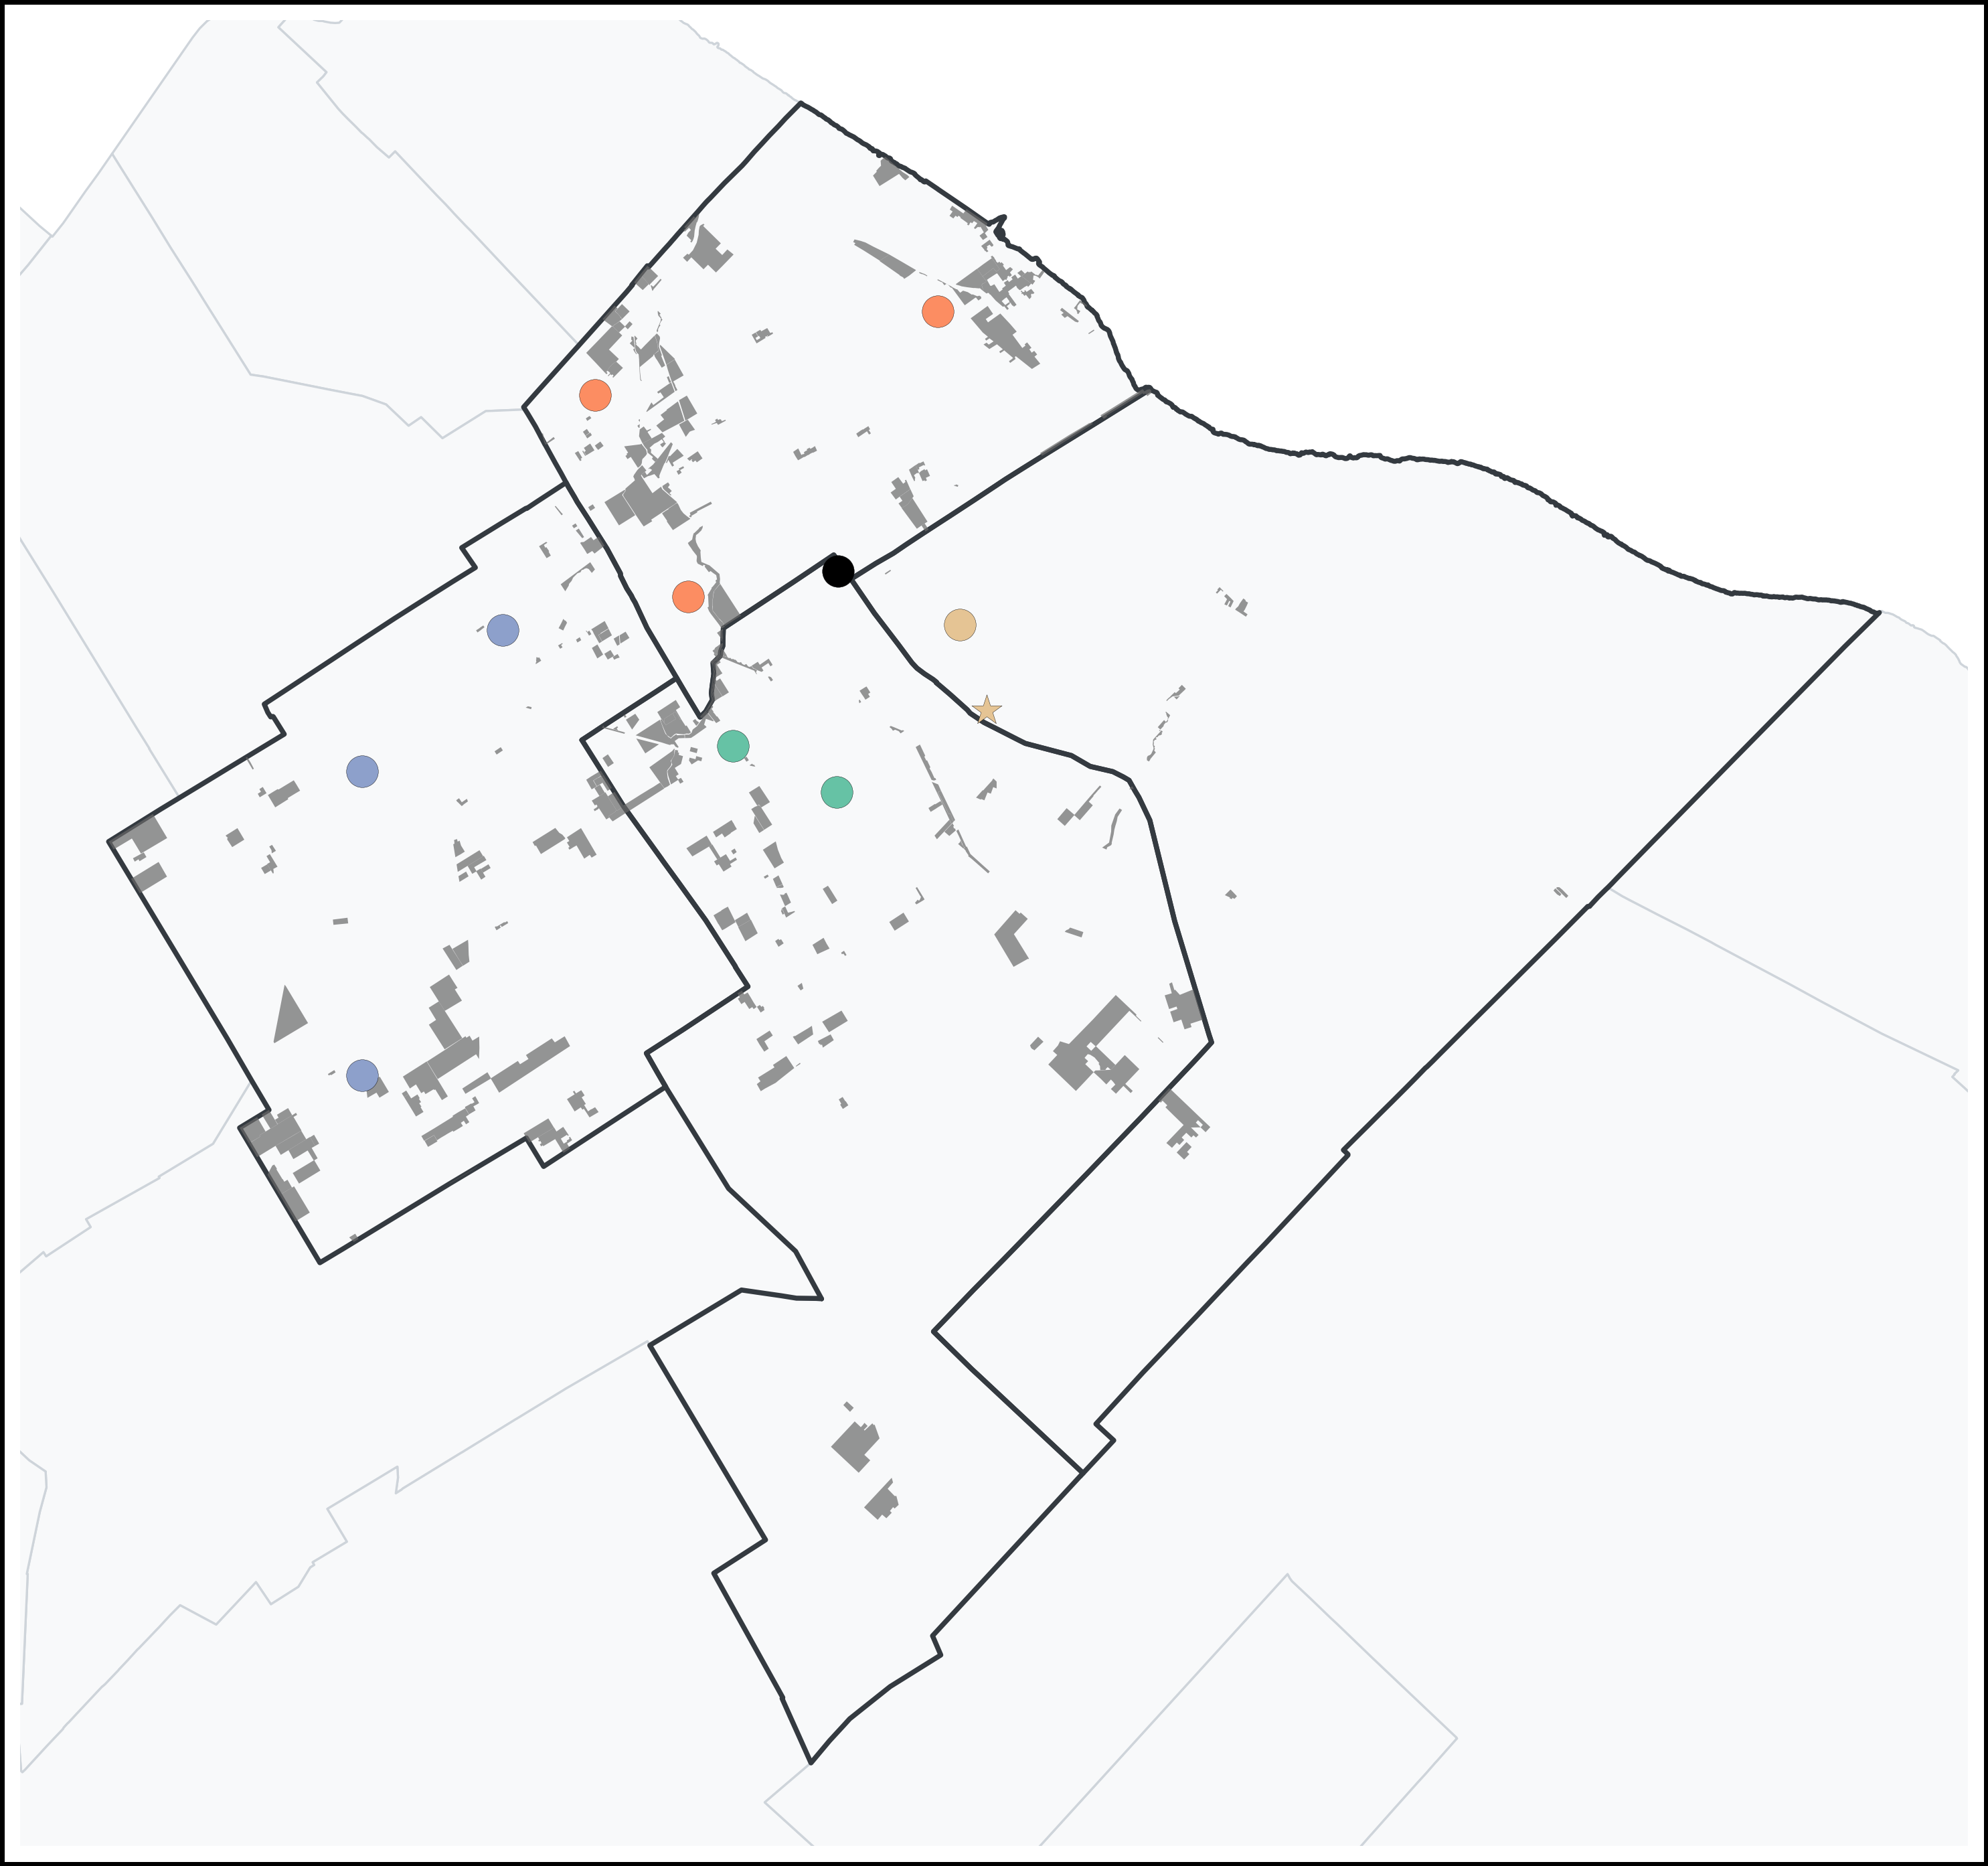

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# ==============================================================================
# 1. CONFIGURACIÓN Y CARGA DE DATOS
# ==============================================================================
print("Cargando datos espaciales...")
deptos = gpd.read_file(RUTA_MUNICIPIOS)
barrios = gpd.read_file(RUTA_BARRIOS_POPULARES)

# Filtrar solo la PBA (códigos que empiezan con 06)
pba = deptos[deptos["in1"].astype(str).str.startswith("06")].copy()

# ==============================================================================
# 2. LIMPIEZA Y FILTRADO DE LA RED SUDESTE
# ==============================================================================
pba["nam_limpio"] = (
    pba["nam"].astype(str).str.upper()
    .str.replace('Á', 'A').str.replace('É', 'E')
    .str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U')
)

red_sudeste_names = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS",
    # "LOMAS DE ZAMORA",
    # "AVELLANEDA",
    "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste_names)]

if sudeste.empty:
    raise ValueError("¡Atención! El filtro sigue sin encontrar municipios.")

# ==============================================================================
# 3. UNIFICACIÓN DE UPAS Y MÓDULOS EN EL MISMO PREDIO
# ==============================================================================
# Diccionario para renombrar la UPA y que abarque a ambos
renombrar_upas = {
    "UPA 17 - QU": "UPA 17 + Módulo 10 - QU",
    "UPA 11 - FV": "UPA 11 + Módulo 11 - FV",
    "UPA 5 - AB": "UPA 5 + Módulo 9 - AB"
}

# Lista de los Módulos que vamos a borrar (porque ya están en la misma coordenada)
modulos_a_eliminar = [
    "Módulo Hospitalario 10 - QU",
    "Módulo Hospitalario 11 - FV",
    "Módulo Hospitalario 9 - AB"
]

# 1. Renombramos las UPAs
df_coordenadas['hospital'] = df_coordenadas['hospital'].replace(renombrar_upas)

# 2. Filtramos para dejar afuera a los módulos duplicados
df_coordenadas = df_coordenadas[~df_coordenadas['hospital'].isin(modulos_a_eliminar)].copy()

# ==============================================================================
# 3.1. CONVERSIÓN DE HOSPITALES A CAPA GEOGRÁFICA
# ==============================================================================
geometry = [Point(xy) for xy in zip(df_coordenadas['lon'], df_coordenadas['lat'])]
hospitales_gdf = gpd.GeoDataFrame(df_coordenadas, geometry=geometry, crs="EPSG:4326")
# ==============================================================================
# 4. PROYECCIÓN ESPACIAL (CRUCIAL PARA ALINEAR TODO)
# ==============================================================================
print("Proyectando a Web Mercator...")
pba = pba.to_crs(epsg=3857)
sudeste = sudeste.to_crs(epsg=3857)
barrios = barrios.to_crs(epsg=3857)
hospitales_gdf = hospitales_gdf.to_crs(epsg=3857) # Proyectamos los hospitales al mismo mapa

# Nos quedamos con los barrios que caen dentro de nuestros municipios
barrios_enfoque = gpd.clip(barrios, sudeste) 

# ==============================================================================
# 5. GRAFICACIÓN CON ETIQUETAS DE HOSPITALES Y LOCALIDADES
# ==============================================================================
print("Generando mapa...")
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
fig.patch.set_facecolor('white')

# A. Municipios de fondo (Gris clarito)
pba.plot(ax=ax, color="#f8f9fa", edgecolor="#ced4da", linewidth=0.8, zorder=1)

# B. Municipios de la Red Sudeste (Borde oscuro grueso)
sudeste.plot(ax=ax, color="none", edgecolor="#343a40", linewidth=1.8, zorder=2)

# C. Nombres de las Localidades (Municipios) - Estilo "Marca de agua"
# for idx, row in sudeste.iterrows():
#     centro = row.geometry.centroid
#     ax.annotate(
#         text=row["nam_limpio"].title(), # .title() lo pone como "Quilmes" en vez de "QUILMES"
#         xy=(centro.x, centro.y),
#         ha='center', va='center',       # Alineación al centro exacto
#         fontsize=12,                    # Letra más grande
#         # fontweight='bold',
#         color='#6c757d',                # Color gris
#         alpha=0.6,                      # Semi-transparente para que no tape los barrios
#         zorder=3                        # Por encima de los polígonos, pero debajo de los barrios y hospitales
#     )

# D. Barrios Populares (Rojo puro)

barrios_enfoque.plot(ax=ax, color="dimgray", edgecolor="none", alpha=0.7, zorder=4)
# barrios_enfoque.plot(ax=ax, color="#a68384", edgecolor="none", alpha=0.7, zorder=4)

# E. Nodos de Hospitales y sus Nombres
TAMAÑO_NODO = 130 
bbox_props = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)

for idx, row in hospitales_gdf.iterrows():
    # 1. Dibujamos el punto del hospital
    ax.scatter(
        row.geometry.x,
        row.geometry.y,
        c=row.get('color_rgb', '#007bff'),
        marker=MAPA_FORMAS.get(row.get('shape', 'o'), 'o') if 'MAPA_FORMAS' in globals() else 'o',
        s=TAMAÑO_NODO,
        edgecolor='black',
        linewidth=0.1,
        zorder=6 
    )
    
    # # 2. Agregamos el nombre del hospital
    # nombre = row.get('hospital', '') 
    # ax.annotate(
    #     text=nombre,
    #     xy=(row.geometry.x, row.geometry.y),
    #     xytext=(8, 8),
    #     textcoords="offset points",
    #     fontsize=10.5,
    #     fontweight='bold',
    #     color='#333333',
    #     bbox=bbox_props,
    #     zorder=7 
    # )
# ==============================================================================
# 6. AJUSTES FINALES (ZOOM Y ESTILO)
# ==============================================================================
ax.axis("off")

# Zoom exacto a la zona de la red sudeste
minx, miny, maxx, maxy = sudeste.total_bounds
margen_x = 0.05 * (maxx - minx)
margen_y = 0.05 * (maxy - miny)
ax.set_xlim(minx - margen_x, maxx + margen_x)
ax.set_ylim(miny - margen_y, maxy + margen_y)

# Marco negro alrededor de la imagen
fig.patch.set_linewidth(3)
fig.patch.set_edgecolor('black')

plt.tight_layout()

# Descomenta la siguiente línea si tienes tu función guardar_pdf definida
guardar_pdf('mapa_contexto_hospitales', subcarpeta='general')
plt.savefig('mapa_contexto_hospitales.svg', format='svg', bbox_inches='tight', transparent=True, dpi=300)


plt.show()